# Package

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# a) Perform commands

In [3]:
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

Voici la forme du modèle : 

Y = 2 + 2*(X1) + 0.3*(x2) + eps

avec eps suit une N(0,1,100)

Les coefficients de la régression sont : 
- B0 : 2
- B1 : 2
- B2 : 0.3

# b) Correlation between x1 and x2

x1 et x2 sont corrélés possitivement puisque le coefficient est égal à 0.5.

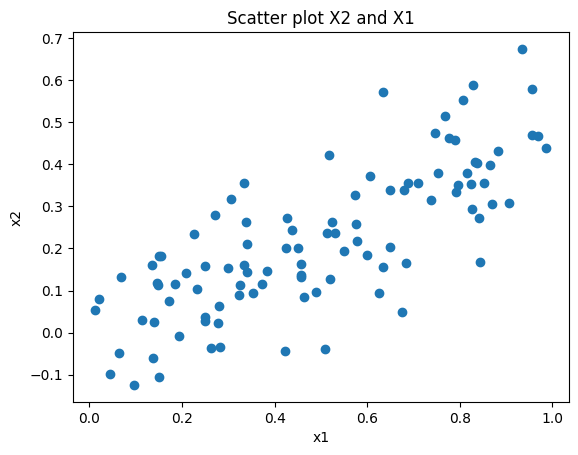

In [8]:
plt.title("Scatter plot X2 and X1")
plt.scatter(x1, x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# c) OLS

In [27]:
x = np.column_stack((x1, x2))
x_const = sm.add_constant(x)

In [32]:
model_1 = sm.OLS(y, x_const).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           5.76e-08
Time:                        16:07:35   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9579      0.190     10.319      0.0

- Le modèle est très significatif au niveau global. En effet, le p-value du test de Fisher est proche de 0 et donc inférieur à 0.01. Il explique environ 29% de la variance de Y. 

- Les valeurs estimatives des coefficients estiment la valeur réelle des coefficients.

- A l'inverse de X1, X2 n'est pas significatif. Son p-value = 0.25 est supérieur au risque d'erreur alpha acceptable = 0.1.

- Une augmentation de 1 unité de X1 fait donc augmenter le Y de 1.61 unité en moyenne, avec les effets des autres variables fixes.

# d) OLS avec Y et X1 uniquement

In [35]:
x_const = sm.add_constant(x1)
model_2 = sm.OLS(y, x_const).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     38.39
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           1.37e-08
Time:                        16:09:05   Log-Likelihood:                -131.28
No. Observations:                 100   AIC:                             266.6
Df Residuals:                      98   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9371      0.189     10.242      0.0

Oui, on peut rejetter H0 sur B1. 

# e) Y et X2 uniquement

In [36]:
x_const = sm.add_constant(x2)
model_3 = sm.OLS(y, x_const).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     27.99
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           7.43e-07
Time:                        16:10:58   Log-Likelihood:                -135.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      98   BIC:                             279.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3239      0.154     15.124      0.0

Oui, je peux rejetter l'hypothèse nulle H0 pour X2 aussi cette fois-ci.

# f) results c) and e) contradictoire

In [ ]:
print("le p_value de X2 dans le modèle_1 est égal à :", model_1.pvalues[2])
print("ce qui suggère que X2 ne contribue pas à Y")
print("le p_value de X2 dans le modèle_3 est égal à :", model_3.pvalues[1])
print("le résultat est contradictoire avec le modèle 1")
print("l'effet de X2 est absorbé par X1 dans le modèle 1")

le p_value de X2 dans le modèle_1 est égal à : 0.2594185944524495
ce qui suggère que X2 ne contribue pas à Y
le p_value de X2 dans le modèle_3 est égal à : 7.429580644947533e-07
le résultat est contradictoire avec le modèle 1


La multicolinéarité fait exploser la variance des coefficients estimés. D'un échantillon à un autre, on peut avoir des coefficients hyper différents. La régression linéaire est donc moins généralisable dans ce sens. 

Dans la pratique, voici des techniques utilisées pour résoudre ce problème ou le contrôler : 
- Sélection des variables ; 
- Réduction de dimension ; 
- Régularisation ; 
- validation croisée.

Nous allons voir ces exercices surtout dans le chapitre 7.